In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
df=pd.read_csv("world_happiness_dataset.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    20 non-null     object 
 1   Happiness_Score            20 non-null     float64
 2   GDP_per_Capita             20 non-null     float64
 3   Social_Support             20 non-null     float64
 4   Healthy_Life_Expectancy    20 non-null     float64
 5   Freedom_to_Make_Choices    20 non-null     float64
 6   Generosity                 20 non-null     float64
 7   Perceptions_of_Corruption  20 non-null     float64
dtypes: float64(7), object(1)
memory usage: 1.4+ KB


In [2]:
df.head(10)

,Country,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom_to_Make_Choices,Generosity,Perceptions_of_Corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10
5,Netherlands,6.41,0.87,0.54,72.6,0.45,0.38,0.36
6,Canada,7.34,0.60,0.46,49.6,1.00,0.07,0.12
7,New Zealand,3.87,0.61,0.57,41.3,0.66,0.26,0.84
8,Australia,5.31,1.43,0.78,53.2,0.36,0.27,0.80
9,Sweden,3.63,1.16,0.62,51.2,0.33,0.57,0.77


In [15]:
df.isna().sum()

Country                      0
Happiness_Score              0
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom_to_Make_Choices      0
Generosity                   0
Perceptions_of_Corruption    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

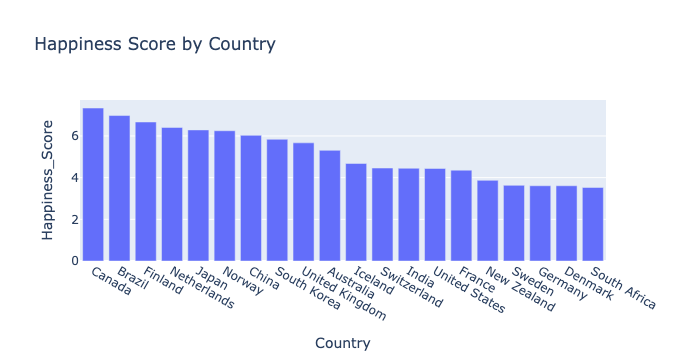

In [5]:
fig = px.bar(
    df.sort_values("Happiness_Score", ascending=False),

    x="Country",
    y="Happiness_Score",

    title="Happiness Score by Country"
)

fig.show()

In [13]:

def plot_outliers_one_frame(df, col):
   

    # =========================
    # IQR
    # =========================
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df.copy()
    df["outlier"] = np.where(
        (df[col] < lower_bound) | (df[col] > upper_bound),
        "Outlier",
        "Normal"
    )

   
    fig = make_subplots(
        rows=1,
        cols=3,
        subplot_titles=("Boxplot", "Histogram", "Outlier Scatter")
    )

    # =========================
    # 1. Boxplot
    # =========================
    box = go.Box(y=df[col], name="Box")
    fig.add_trace(box, row=1, col=1)

    # =========================
    # 2. Histogram
    # =========================
    hist = go.Histogram(x=df[col], nbinsx=30, name="Hist")
    fig.add_trace(hist, row=1, col=2)

    # =========================
    # 3. Scatter (outliers)
    # =========================
    colors = df["outlier"].map({"Normal": "blue", "Outlier": "red"})

    scatter = go.Scatter(
    x=df.index,
    y=df[col],
    mode="markers+text",

    text=np.where(
        df["outlier"] == "Outlier",
        df[col].round(2),
        ""
    ),

    textposition="top center",

    marker=dict(
        color=colors,
        size=np.where(df["outlier"] == "Outlier", 12, 6)
    ),

    name="Outliers",

    hovertemplate=
    "<b>Index:</b> %{x}<br>" +
    "<b>Value:</b> %{y}<br>" +
    "<b>Status:</b> %{text}<extra></extra>"
    )
    fig.add_trace(scatter, row=1, col=3)

    # =========================
    # layout
    # =========================
    fig.update_layout(
        title=f"Outlier Analysis - {col}",
        height=400,
        showlegend=False
    )

    fig.show()

    return df

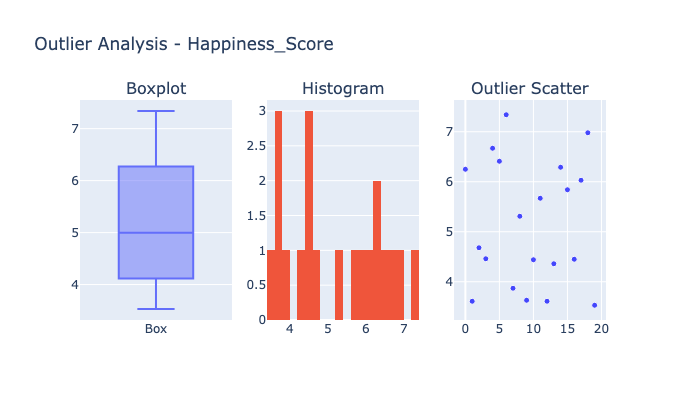

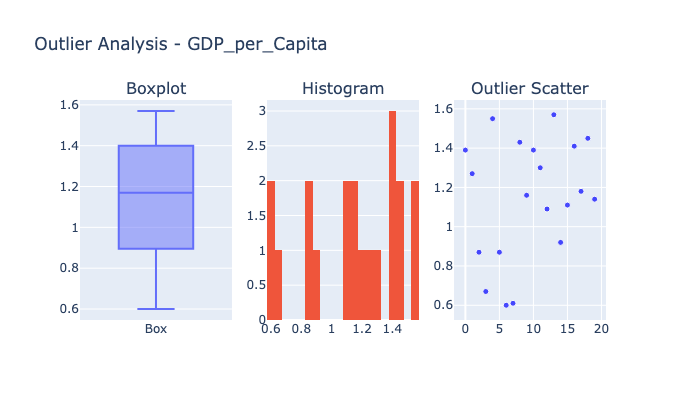

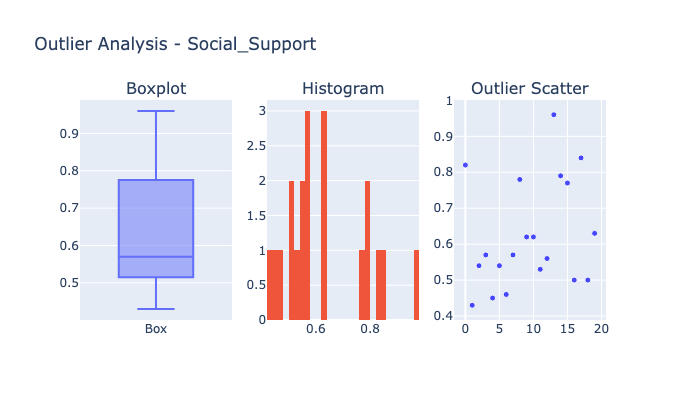

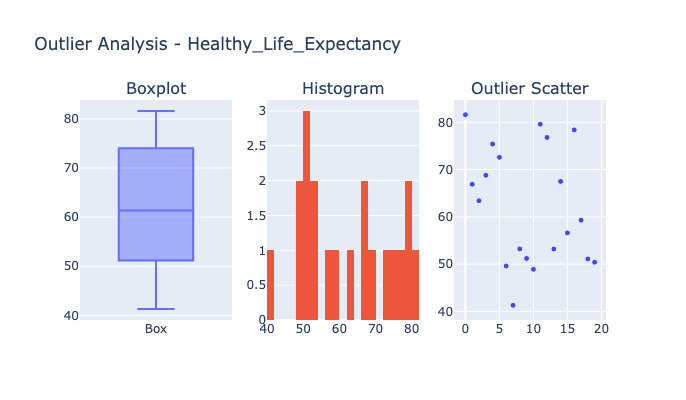

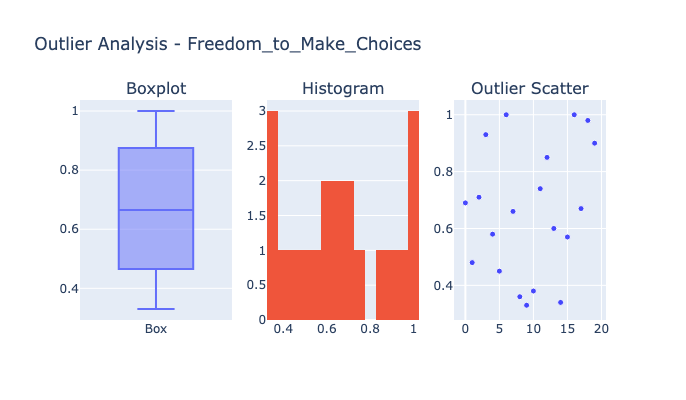

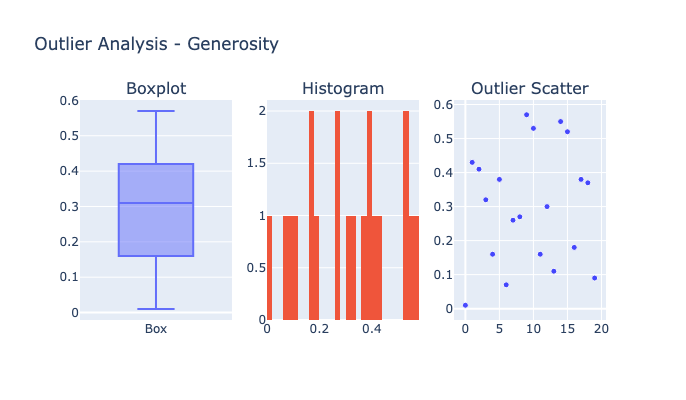

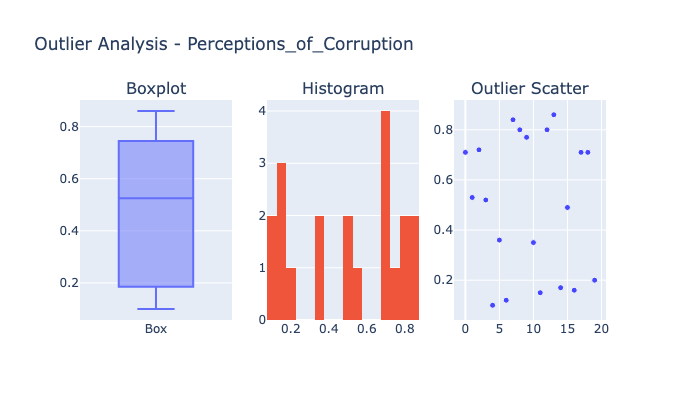

In [14]:
for item in ["Happiness_Score",	"GDP_per_Capita",	"Social_Support",	"Healthy_Life_Expectancy",	"Freedom_to_Make_Choices",	"Generosity",	"Perceptions_of_Corruption"]:
    plot_outliers_one_frame(df,item)

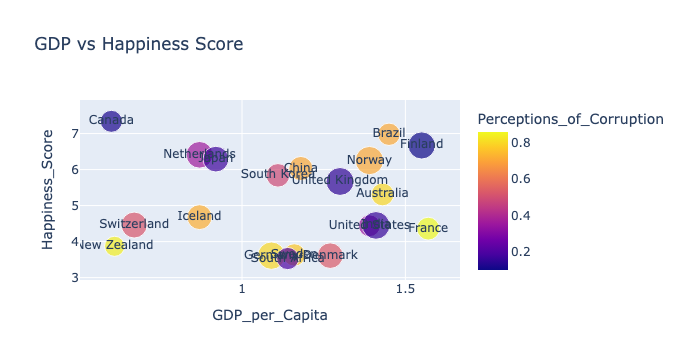

In [17]:
fig = px.scatter(
    df,

    x="GDP_per_Capita",
    y="Happiness_Score",

    text="Country",

    size="Healthy_Life_Expectancy",

    color="Perceptions_of_Corruption",

    title="GDP vs Happiness Score"
)

fig.show()

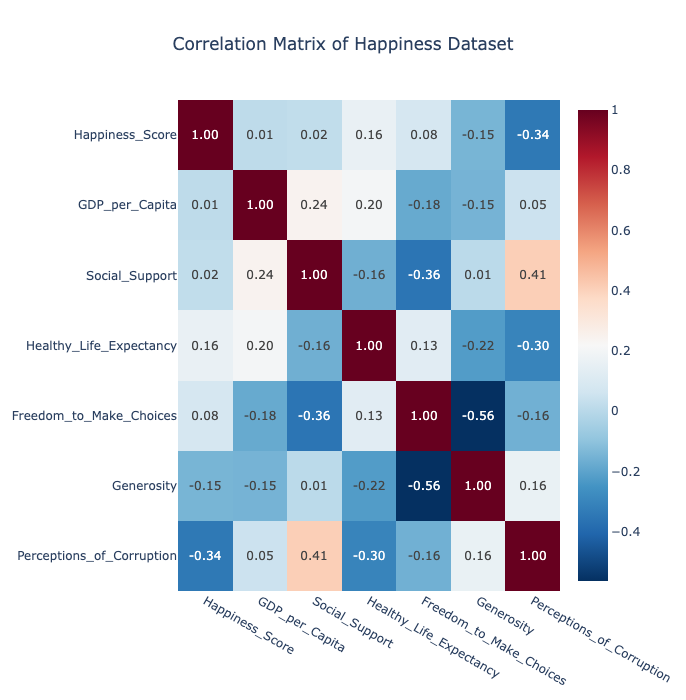

In [19]:
corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,

    text_auto=".2f",

    aspect="auto",

    color_continuous_scale="RdBu_r",

    title="Correlation Matrix of Happiness Dataset"
)

fig.update_layout(
    width=900,
    height=700,

    title_x=0.5
)

fig.show()